In [1]:
%pip install seaborn matplotlib
%pip install scikit-learn
%pip install imbalanced-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Load Titanic dataset ONCE
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df = sns.load_dataset("titanic")
df.head()


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sai20\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sai20\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sai20\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dataset loaded successfully.
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [47]:
# Task 1 — Dataset profiling

print("DATASET INFO")
print("=" * 60)
df.info()

print("\nDATASET SHAPE")
print("=" * 60)
print(df.shape)

print("\nNUMERICAL SUMMARY")
print("=" * 60)
display(df.describe())

print("\nMISSING VALUES")
print("=" * 60)

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(
    missing_summary[missing_summary["missing_count"] > 0]
)

DATASET INFO
<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    str     
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        889 non-null    category
 9   who          889 non-null    str     
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        889 non-null    str     
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 86.1 KB

DATASET SHAPE
(889, 14)

NUMERICAL SUMMARY


,survived,pclass,age,sibsp,parch,fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



MISSING VALUES


,missing_count,missing_percentage


In [48]:
# Save the dataset for offline use by the modeling notebook
output_path = "titanic.csv"
df.to_csv(output_path, index=False)

print(f"Dataset saved successfully to: {output_path}")

Dataset saved successfully to: titanic.csv


In [49]:
# Task 2 — Missing-value handling

missing_pct = df.isna().mean() * 100

# Drop columns with >40% missing values
drop_columns = missing_pct[missing_pct > 40].index
df = df.drop(columns=drop_columns)

# 5%–40% missing:
# median for numeric columns, mode for categorical columns
for col in df.columns:
    if 5 <= missing_pct[col] <= 40:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# <5% missing: drop rows
for col in df.columns:
    if missing_pct[col] < 5 and df[col].isna().any():
        df = df.dropna(subset=[col])

print("Missing-value handling completed.")
print("Shape:", df.shape)
print("Remaining missing values:")
print(df.isna().sum())

Missing-value handling completed.
Shape: (889, 14)
Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


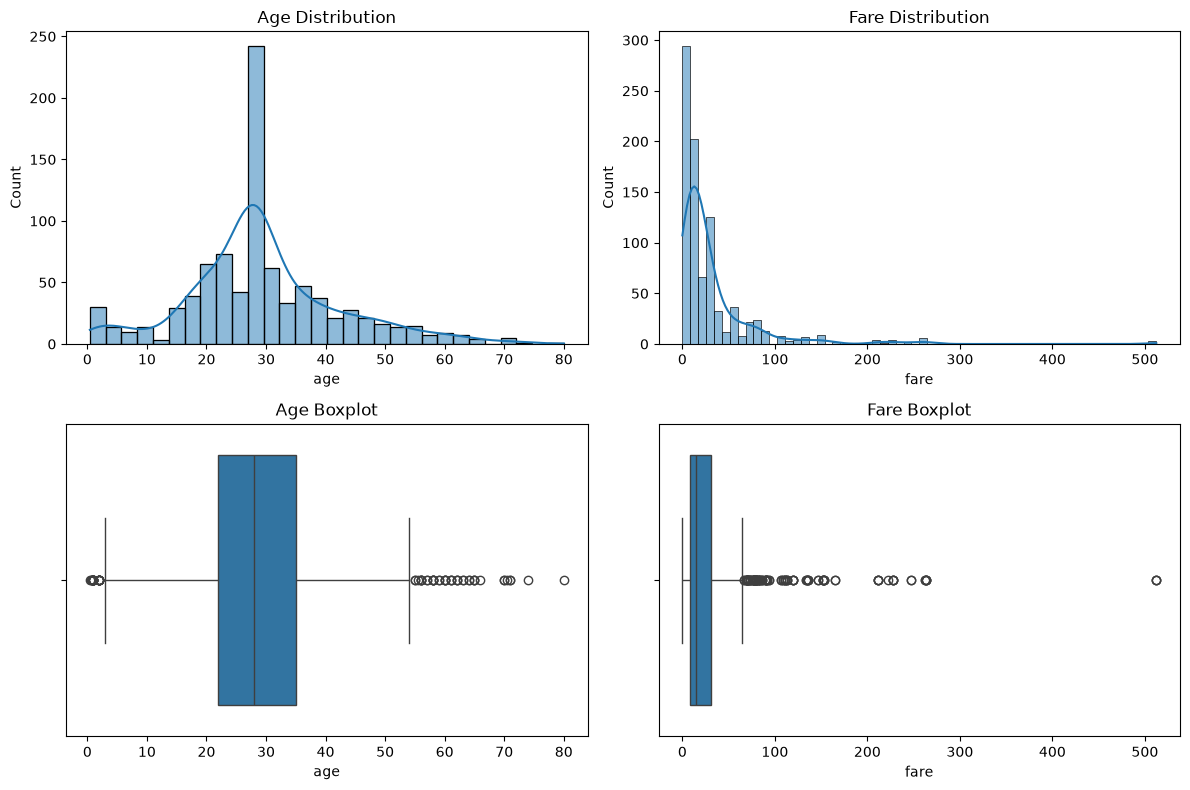

Age IQR outlier count: 65
Fare IQR outlier count: 114
Fare skewness: 4.8


In [50]:
# Task 3 — Distributions and outliers

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["fare"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Fare Distribution")

sns.boxplot(x=df["age"], ax=axes[1, 0])
axes[1, 0].set_title("Age Boxplot")

sns.boxplot(x=df["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Boxplot")

plt.tight_layout()
plt.show()


# IQR outlier counts

def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return ((series < lower_bound) | (series > upper_bound)).sum()


age_outliers = iqr_outlier_count(df["age"])
fare_outliers = iqr_outlier_count(df["fare"])

print("Age IQR outlier count:", age_outliers)
print("Fare IQR outlier count:", fare_outliers)

print("Fare skewness:", round(df["fare"].skew(), 2))

Survival rate by sex:


,sex,survival_rate
0,female,0.740385
1,male,0.188908



Survival rate by passenger class:


,pclass,survival_rate
0,1,0.626168
1,2,0.472826
2,3,0.242363



Survival rate by sex and passenger class:


,sex,pclass,survival_rate
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447



Correlation Matrix:


,age,fare,pclass,sibsp,parch,survived
age,1.000000,0.093707,-0.336512,-0.232543,-0.171485,-0.069822
fare,0.093707,1.000000,-0.548193,0.160887,0.217532,0.255290
pclass,-0.336512,-0.548193,1.000000,0.081656,0.016824,-0.335549
sibsp,-0.232543,0.160887,0.081656,1.000000,0.414542,-0.034040
parch,-0.171485,0.217532,0.016824,0.414542,1.000000,0.083151
survived,-0.069822,0.255290,-0.335549,-0.034040,0.083151,1.000000


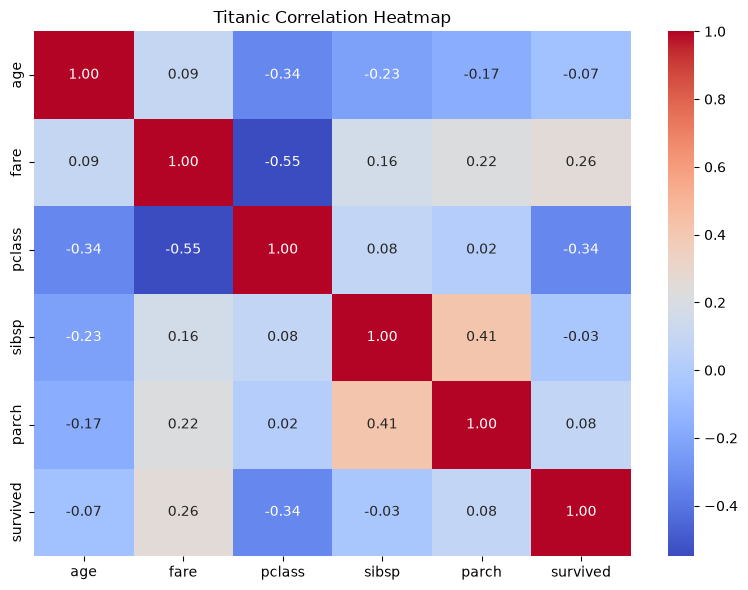

In [51]:
# Task 4 — Survival analysis and correlation

print("Survival rate by sex:")
display(df.groupby("sex")["survived"].mean().reset_index(name="survival_rate"))

print("\nSurvival rate by passenger class:")
display(df.groupby("pclass")["survived"].mean().reset_index(name="survival_rate"))

print("\nSurvival rate by sex and passenger class:")
display(
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .reset_index(name="survival_rate")
)

# Required 6-column correlation matrix
corr_cols = ["age", "fare", "pclass", "sibsp", "parch", "survived"]
correlation_matrix = df[corr_cols].corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()

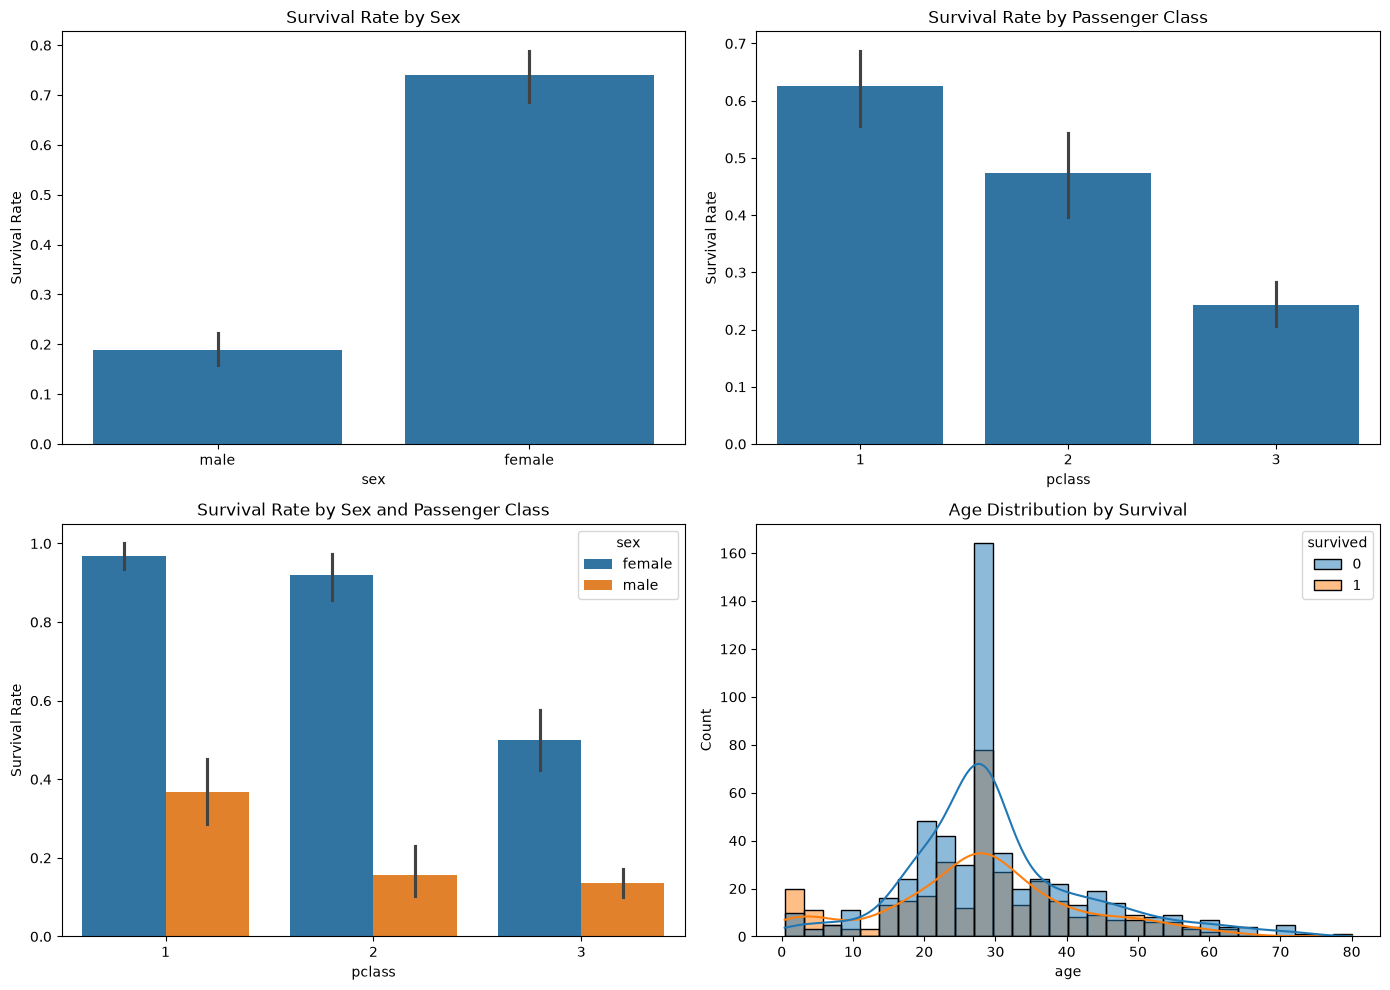

In [52]:
# Task 5 — Meaningful visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Sex
sns.barplot(data=df, x="sex", y="survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_ylabel("Survival Rate")

# 2. Survival by Passenger Class
sns.barplot(data=df, x="pclass", y="survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Passenger Class")
axes[0, 1].set_ylabel("Survival Rate")

# 3. Survival by Sex and Passenger Class
sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[1, 0])
axes[1, 0].set_title("Survival Rate by Sex and Passenger Class")
axes[1, 0].set_ylabel("Survival Rate")

# 4. Age Distribution by Survival
sns.histplot(
    data=df,
    x="age",
    hue="survived",
    kde=True,
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Age Distribution by Survival")

plt.tight_layout()
plt.show()

In [53]:
# Task 6 — Standardization sanity check

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standardized = scaler.fit_transform(df[["age", "fare"]])

standardized_df = pd.DataFrame(
    standardized,
    columns=["age_standardized", "fare_standardized"]
)

print("Standardized variables summary:")
display(standardized_df.describe().loc[["mean", "std"]])

Standardized variables summary:


,age_standardized,fare_standardized
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00


In [54]:
# Task 7 — Stratified train/test split

from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (711, 13)
Testing set: (178, 13)
Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [58]:
# Task 8 — Preprocessing pipeline

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nPreprocessing pipeline created successfully.")

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']

Preprocessing pipeline created successfully.


C:\Users\sai20\AppData\Local\Temp\ipykernel_9768\3424686840.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [59]:
# Fix X, y, train/test split — remove target leakage

X = df.drop(columns=["survived", "alive"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X columns:")
print(X.columns.tolist())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']

X_train shape: (711, 12)
X_test shape: (178, 12)


In [60]:
# Task 9 — Classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: trained successfully")

Logistic Regression: trained successfully
Decision Tree: trained successfully
Random Forest: trained successfully



Logistic Regression
----------------------------------------
Confusion Matrix:
[[98 12]
 [21 47]]
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402
ROC-AUC  : 0.8686


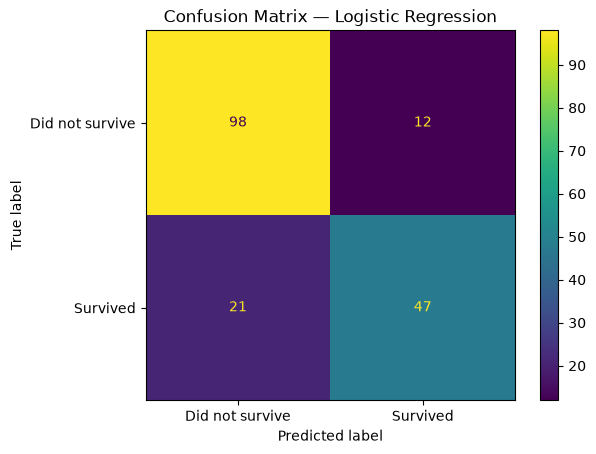


Decision Tree
----------------------------------------
Confusion Matrix:
[[94 16]
 [19 49]]
Accuracy : 0.8034
Precision: 0.7538
Recall   : 0.7206
F1 Score : 0.7368
ROC-AUC  : 0.7814


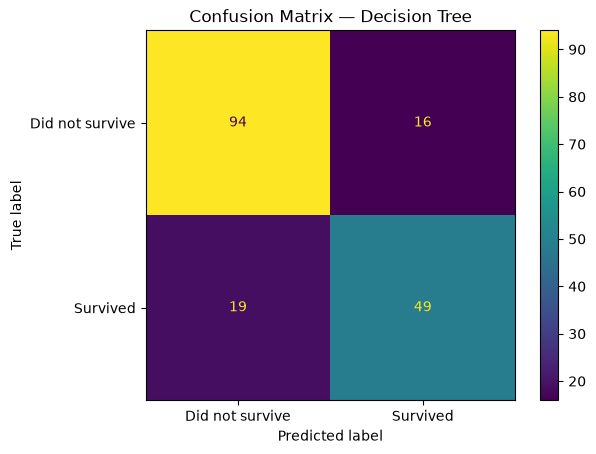


Random Forest
----------------------------------------
Confusion Matrix:
[[92 18]
 [23 45]]
Accuracy : 0.7697
Precision: 0.7143
Recall   : 0.6618
F1 Score : 0.6870
ROC-AUC  : 0.8110


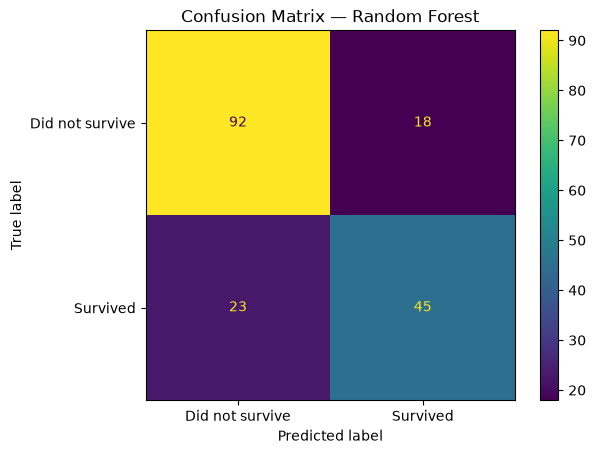


Final Evaluation Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868583
1,Decision Tree,0.803371,0.753846,0.720588,0.736842,0.781417
2,Random Forest,0.769663,0.714286,0.661765,0.687023,0.810963


In [61]:
# Task 10 — Classification evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

evaluation_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    })

    print(f"\n{name}")
    print("-" * 40)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Did not survive", "Survived"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

evaluation_df = pd.DataFrame(evaluation_results)

print("\nFinal Evaluation Comparison:")
display(evaluation_df)

In [62]:
# Task 11 — Class imbalance comparison

from imblearn.over_sampling import SMOTE

imbalance_results = []

# 1. Baseline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

imbalance_results.append({
    "Approach": "Baseline",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred)
})


# 2. class_weight='balanced'
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)

imbalance_results.append({
    "Approach": "class_weight='balanced'",
    "Accuracy": accuracy_score(y_test, balanced_pred),
    "Precision": precision_score(y_test, balanced_pred),
    "Recall": recall_score(y_test, balanced_pred),
    "F1": f1_score(y_test, balanced_pred)
})


# 3. SMOTE
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

X_test_processed = preprocessor.transform(X_test)
smote_pred = smote_model.predict(X_test_processed)

imbalance_results.append({
    "Approach": "SMOTE",
    "Accuracy": accuracy_score(y_test, smote_pred),
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred)
})


imbalance_df = pd.DataFrame(imbalance_results)

print("Class Imbalance Comparison:")
display(imbalance_df)

Class Imbalance Comparison:


,Approach,Accuracy,Precision,Recall,F1
0,Baseline,0.814607,0.796610,0.691176,0.740157
1,class_weight='balanced',0.831461,0.779412,0.779412,0.779412
2,SMOTE,0.820225,0.781250,0.735294,0.757576


### Class Imbalance Conclusion

The class-weighted Logistic Regression performed best overall, achieving the highest accuracy (83.15%) and F1 score (77.94%), while also improving recall to 77.94% compared with the baseline model. SMOTE also improved recall and F1 compared with the baseline, but its performance was slightly lower than the class-weighted approach. Therefore, class weighting was the most effective imbalance-handling method for this dataset.

In [63]:
# Task 12 — Random Forest GridSearchCV + OOB score

from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

# Required hyperparameters
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(grid_search.best_score_, 4))

print("\nOOB Score:")
print(round(best_rf.named_steps["model"].oob_score_, 4))

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best Cross-Validation F1:
0.7515

OOB Score:
0.8172


In [64]:
# Task 13 — Final Random Forest evaluation

best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

final_rf_results = {
    "Accuracy": accuracy_score(y_test, best_rf_pred),
    "Precision": precision_score(y_test, best_rf_pred),
    "Recall": recall_score(y_test, best_rf_pred),
    "F1": f1_score(y_test, best_rf_pred),
    "ROC_AUC": roc_auc_score(y_test, best_rf_prob)
}

print("Tuned Random Forest Test Results")
print("=" * 45)

for metric, value in final_rf_results.items():
    print(f"{metric}: {value:.4f}")

Tuned Random Forest Test Results
Accuracy: 0.7865
Precision: 0.7500
Recall: 0.6618
F1: 0.7031
ROC_AUC: 0.8130


Regression Results:


,Model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,20.686678,42.570640,0.320728,0.305022
1,Ridge Regression,20.664717,42.569652,0.320760,0.305055


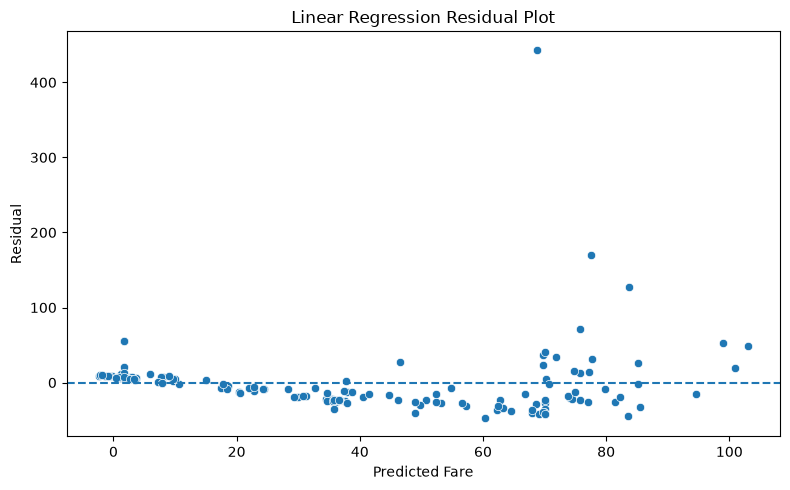

In [65]:
# Task 13 — Regression

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_features = ["age", "pclass", "sibsp", "parch"]

X_reg = df[regression_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

linear_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", Ridge())
])

linear_model.fit(X_reg_train, y_reg_train)
ridge_model.fit(X_reg_train, y_reg_train)

linear_pred = linear_model.predict(X_reg_test)
ridge_pred = ridge_model.predict(X_reg_test)


def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


n = len(y_reg_test)
p = len(regression_features)

linear_r2 = r2_score(y_reg_test, linear_pred)
ridge_r2 = r2_score(y_reg_test, ridge_pred)

regression_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mean_absolute_error(y_reg_test, linear_pred),
        "RMSE": mean_squared_error(y_reg_test, linear_pred) ** 0.5,
        "R2": linear_r2,
        "Adjusted_R2": adjusted_r2(linear_r2, n, p)
    },
    {
        "Model": "Ridge Regression",
        "MAE": mean_absolute_error(y_reg_test, ridge_pred),
        "RMSE": mean_squared_error(y_reg_test, ridge_pred) ** 0.5,
        "R2": ridge_r2,
        "Adjusted_R2": adjusted_r2(ridge_r2, n, p)
    }
])

print("Regression Results:")
display(regression_results)


# Residual plot
residuals = y_reg_test - linear_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=linear_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")
plt.tight_layout()
plt.show()

### Residual Interpretation

The residuals are centered around zero but show some variation in spread across the predicted values. A few large residuals are also present, indicating possible outliers and some evidence of non-constant variance. Therefore, the linear regression model does not capture all variation in fare equally well across the prediction range.

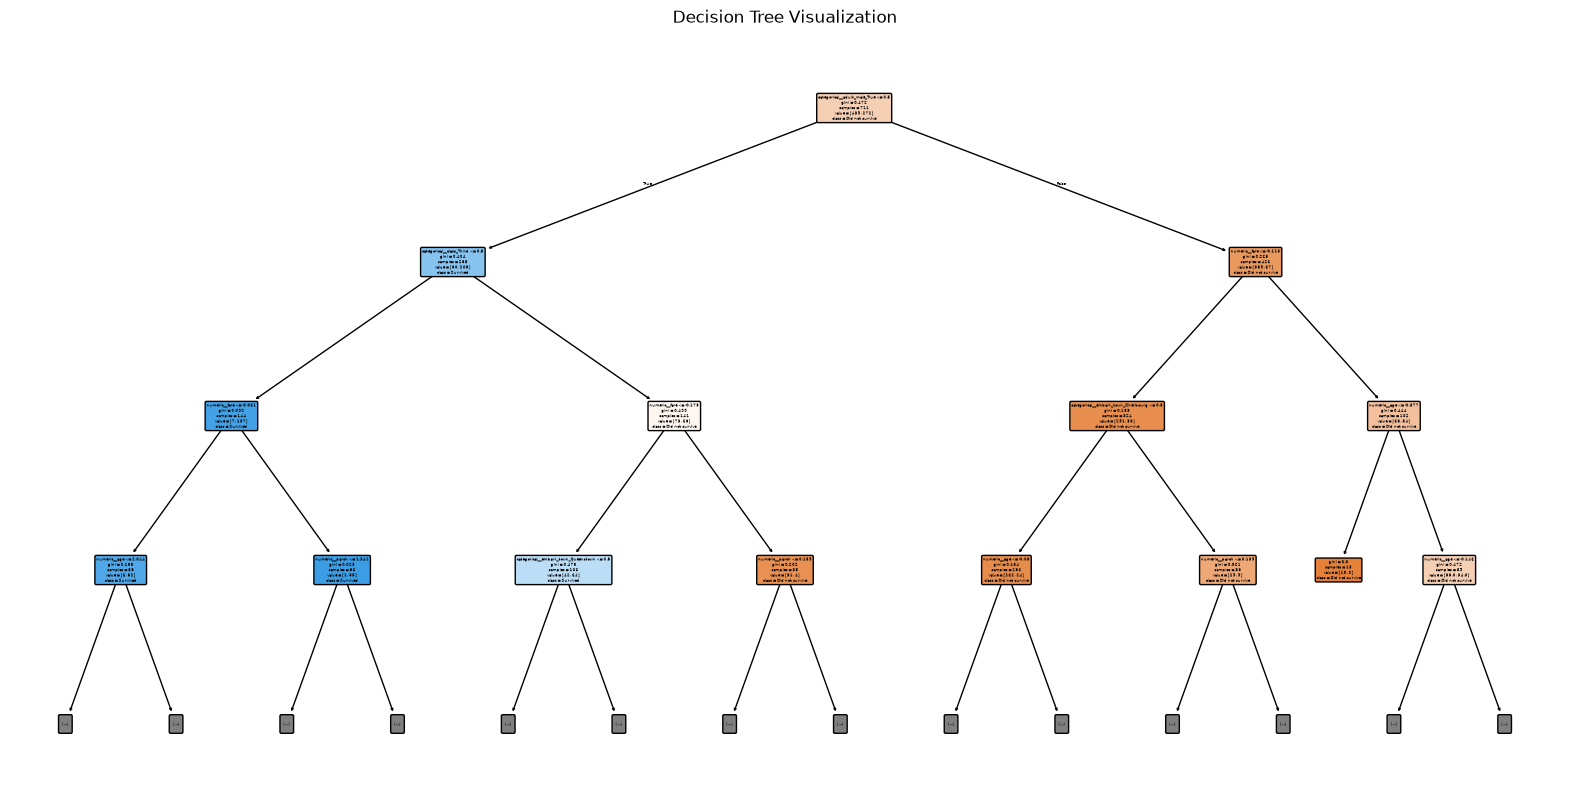

In [66]:
# Task 14 — Decision Tree visualization

from sklearn.tree import plot_tree

decision_tree_model = models["Decision Tree"]

# Get the fitted Decision Tree from the pipeline
tree = decision_tree_model.named_steps["model"]

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    max_depth=3,
    feature_names=decision_tree_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

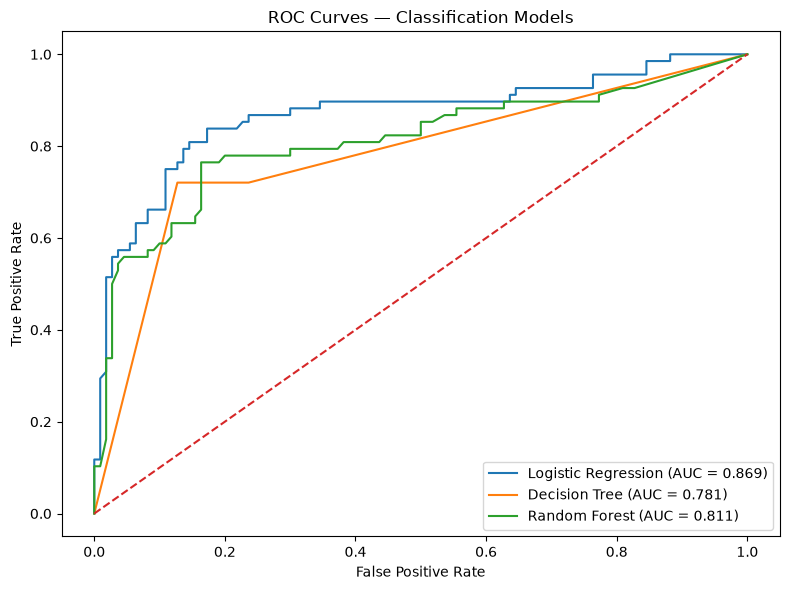

In [67]:
# ROC curves — Logistic Regression, Decision Tree, Random Forest

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# Correlation analysis — strongest relationships

corr_cols = ["age", "fare", "pclass", "sibsp", "parch", "survived"]

corr_matrix = df[corr_cols].corr()

# Get strongest absolute correlations excluding self-correlations
corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Two strongest correlations:")
display(corr_pairs.head(2))

Two strongest correlations:


fare   pclass   -0.548193
sibsp  parch     0.414542
dtype: float64

### Correlation Interpretation

The strongest correlation is between `fare` and `pclass`, with a correlation of -0.5482, indicating a moderate negative relationship. This means higher passenger class numbers are generally associated with lower fares. The second strongest correlation is between `sibsp` and `parch`, with a correlation of 0.4145, indicating a moderate positive relationship, where passengers traveling with more siblings/spouses also tend to have more parents/children aboard. These correlations represent associations and do not imply causation.

In [38]:
# Display class imbalance results

display(imbalance_df)

,Approach,Accuracy,Precision,Recall,F1
0,Baseline,0.814607,0.796610,0.691176,0.740157
1,class_weight='balanced',0.831461,0.779412,0.779412,0.779412
2,SMOTE,0.820225,0.781250,0.735294,0.757576


In [69]:
print("Target distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Target distribution:
survived
0    439
1    272
Name: count, dtype: int64

Test distribution:
survived
0    110
1     68
Name: count, dtype: int64

X_train shape: (711, 12)
X_test shape: (178, 12)


In [70]:
# Check for target leakage and inspect the feature columns

print("X columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

print("\nTest predictions:")
print(pd.crosstab(
    y_test,
    baseline_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
))

print("\nUnique values in each feature:")
display(X.nunique().sort_values())

X columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']

Target column:
survived

Test predictions:
Predicted   0   1
Actual           
0          98  12
1          21  47

Unique values in each feature:


sex              2
adult_male       2
alone            2
pclass           3
embark_town      3
who              3
embarked         3
class            3
sibsp            7
parch            7
age             88
fare           247
dtype: int64

In [42]:
# Fix target leakage

X = df.drop(columns=["survived", "alive"])
y = df["survived"]

print("Features after removing target leakage:")
print(X.columns.tolist())

Features after removing target leakage:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']


In [71]:
# Final Model Comparison

print("CLASSIFICATION MODEL COMPARISON")
display(evaluation_df)

print("\nREGRESSION MODEL COMPARISON")
display(regression_results)

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.814607,0.796610,0.691176,0.740157,0.868583
1,Decision Tree,0.803371,0.753846,0.720588,0.736842,0.781417
2,Random Forest,0.769663,0.714286,0.661765,0.687023,0.810963



REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,20.686678,42.570640,0.320728,0.305022
1,Ridge Regression,20.664717,42.569652,0.320760,0.305055


In [72]:
# Task 15 — Save the complete final pipeline

import joblib

full_pipeline = balanced_model

joblib.dump(full_pipeline, "titanic_final_pipeline.joblib")

print("Complete pipeline saved successfully.")

Complete pipeline saved successfully.


In [73]:
# Reload and test the saved pipeline

loaded_pipeline = joblib.load("titanic_final_pipeline.joblib")

raw_test_sample = X_test.iloc[:5]

loaded_predictions = loaded_pipeline.predict(raw_test_sample)

print("Reloaded pipeline predictions:")
print(loaded_predictions)

print("\nActual values:")
print(y_test.iloc[:5].values)

print("\nPipeline reload test successful.")

Reloaded pipeline predictions:
[0 0 0 0 0]

Actual values:
[0 0 0 0 0]

Pipeline reload test successful.
